In [21]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
import os
import torch
from src.Architectures.Models import get_model
from sklearn.model_selection import ParameterGrid
from src.core.EgammaNpzDataset import EgammaNpzDataset
from src.core.Trainer import Trainer
from src.Architectures.Models import get_model

In [12]:
ET_INX = 1
ETA_INX = 0
DATA_PATH = Path(os.path.join("results","modelV1.dim0.5.folds10_id20260218132858", f"iet{ET_INX}.ieta{ETA_INX}.pkl")) 
DATA_PATH = DATA_PATH.resolve() 
DATA_PATH = str(DATA_PATH)

In [13]:
try:
    with open(DATA_PATH, 'rb') as file:
        data = pd.read_pickle(file)
        print("Data loaded successfully:")
except FileNotFoundError:
    print(f"Error: The file '{DATA_PATH}' was not found.")
except Exception as e:
    print(f"An error occurred: {e}")

Data loaded successfully:


In [10]:
results_data = data[['file_path', 'fold', 'best_sp_value', 'best_fa_value', 'best_pd_value', 'history']]

In [11]:
results_data.head()

,file_path,fold,best_sp_value,best_fa_value,best_pd_value,history
0,/eos/user/j/jlieberm/photonRinger/datasets/not...,0,0.787576,0.131192,0.710335,"{'train_loss': [0.41743324478533095, 0.3754204..."
1,/eos/user/j/jlieberm/photonRinger/datasets/not...,1,0.787155,0.122646,0.701855,"{'train_loss': [0.4066415443446827, 0.37323137..."
2,/eos/user/j/jlieberm/photonRinger/datasets/not...,2,0.788699,0.135385,0.716274,"{'train_loss': [0.3986269039066704, 0.37244031..."
3,/eos/user/j/jlieberm/photonRinger/datasets/not...,3,0.791005,0.110540,0.698333,"{'train_loss': [0.4253148743712629, 0.37748124..."
4,/eos/user/j/jlieberm/photonRinger/datasets/not...,4,0.791359,0.130796,0.717170,"{'train_loss': [0.40596385465899276, 0.3734883..."


In [50]:
index_best_result = results_data.sort_values(by='best_sp_value').head(3).index[0]

In [17]:
drive_path = '/eos/user/j/jlieberm/photonRinger/datasets/notIso'
trainer = Trainer()
eta_et_region = list(ParameterGrid({'eta': [ETA_INX], 'et': [ET_INX]}))
data_folder = [os.path.join(drive_path, file) for file in os.listdir(drive_path)
                if (file.endswith(".npz") and 
                    file.startswith("mc23_13TeV"))]
full_dataset = EgammaNpzDataset(data_folder, percentage=0.5)

data_array, target,  path = full_dataset[0]
test_data, _ = trainer.generate_folds_with_holdout(data_array, target)

In [18]:
model = get_model("V1", 50)
model.load_state_dict(data.loc[index_best_result]["best_weights"])

<All keys matched successfully>

In [19]:
data_array[test_data].shape

(67683, 50)

In [26]:
model.eval()
test_tensor = torch.Tensor(data_array[test_data])
with torch.no_grad():
    probs = model(test_tensor)
labels = target[test_data]

In [48]:
target_pd = 0.75 
scores_sinal = probs[labels == 1]
percentil_corte = (1 - target_pd) * 100
print(f"percentil corte = {percentil_corte:.2f}")
novo_limiar = np.percentile(scores_sinal.detach().numpy(), percentil_corte)
print(f"Limiar ajustado para PD: {novo_limiar * 100:.2f}%")

scores_ruido = probs[labels == 0]
falsos_alarmes = (scores_ruido > novo_limiar).sum()
pf = falsos_alarmes / len(scores_ruido)

print(f"Com PD fixado em {target_pd * 100:.2f}%, o PF obtido foi: {pf * 100:.2f}%")

percentil corte = 25.00
Limiar ajustado para PD: 79.05%
Com PD fixado em 75.00%, o PF obtido foi: 13.54%


# Analysis

In [90]:
DATA_PATH = Path(os.path.join("/", "eos","user","j","jlieberm","photonRinger","datasets","notIso")) 
DATA_PATH = DATA_PATH.resolve() 
DATA_PATH = str(DATA_PATH)
ETA_INX = 1
ET_INX = 0
FILE_NAME_TAMPLATE = F"mc23_13TeV.sgn.gammajet.bkg.vetoMC.dijet_et{ET_INX}_eta{ETA_INX}.npz"

In [98]:
file_path = os.path.join(DATA_PATH,FILE_NAME_TAMPLATE)
print(f"{file_path = }")
source_data = np.load(file_path)
for k in source_data.keys():
    print(k)

file_path = '/eos/home-i01/j/jlieberm/photonRinger/datasets/notIso/mc23_13TeV.sgn.gammajet.bkg.vetoMC.dijet_et0_eta1.npz'
features
etBins
etaBins
etBinIdx
etaBinIdx
data
target


In [95]:
source_data["features"]

array(['avgmu', 'L2Calo_ring_0', 'L2Calo_ring_1', 'L2Calo_ring_2',
       'L2Calo_ring_3', 'L2Calo_ring_4', 'L2Calo_ring_5', 'L2Calo_ring_6',
       'L2Calo_ring_7', 'L2Calo_ring_8', 'L2Calo_ring_9',
       'L2Calo_ring_10', 'L2Calo_ring_11', 'L2Calo_ring_12',
       'L2Calo_ring_13', 'L2Calo_ring_14', 'L2Calo_ring_15',
       'L2Calo_ring_16', 'L2Calo_ring_17', 'L2Calo_ring_18',
       'L2Calo_ring_19', 'L2Calo_ring_20', 'L2Calo_ring_21',
       'L2Calo_ring_22', 'L2Calo_ring_23', 'L2Calo_ring_24',
       'L2Calo_ring_25', 'L2Calo_ring_26', 'L2Calo_ring_27',
       'L2Calo_ring_28', 'L2Calo_ring_29', 'L2Calo_ring_30',
       'L2Calo_ring_31', 'L2Calo_ring_32', 'L2Calo_ring_33',
       'L2Calo_ring_34', 'L2Calo_ring_35', 'L2Calo_ring_36',
       'L2Calo_ring_37', 'L2Calo_ring_38', 'L2Calo_ring_39',
       'L2Calo_ring_40', 'L2Calo_ring_41', 'L2Calo_ring_42',
       'L2Calo_ring_43', 'L2Calo_ring_44', 'L2Calo_ring_45',
       'L2Calo_ring_46', 'L2Calo_ring_47', 'L2Calo_ring_48',
       

In [96]:
eratio_index = np.where(source_data["features"] == "eratio")[0][0]
source_eratio = source_data["data"][:,eratio_index]
source_target = source_data["target"]

(175556,)
(38632,)


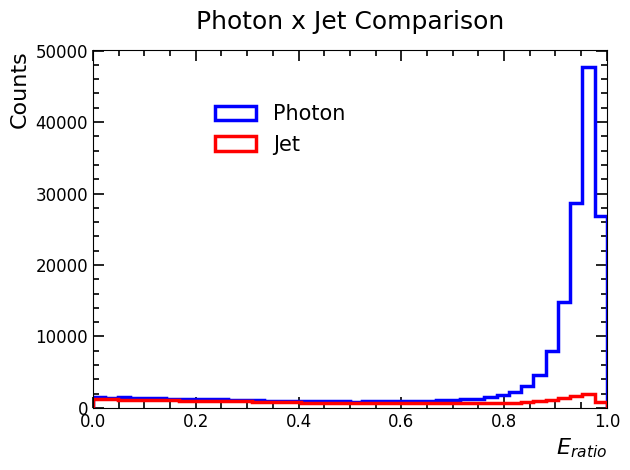

In [117]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

signal_eratio = source_eratio[np.where(source_target == 1)]
print(f"{signal_eratio.shape}")
background_eratio = source_eratio[np.where(source_target == 0)]
print(f"{background_eratio.shape}")

bins = 42
range_x = (0, 1)
ax.hist(signal_eratio, bins=bins, range=range_x, histtype='step', 
        color='blue', linewidth=2.5, label='Photon')
ax.hist(background_eratio, bins=bins, range=range_x, histtype='step', 
        color='red', linewidth=2.5, label='Jet')
ax.minorticks_on() 
ax.tick_params(axis='both', which='both', direction='in', 
               top=True, right=True, width=1.2)
ax.tick_params(axis='both', which='major', length=8, labelsize=12)
ax.tick_params(axis='both', which='minor', length=4)

ax.set_title("Photon x Jet Comparison", fontsize=18, pad=15)
ax.set_xlabel(r"$E_{ratio}$", fontsize=16, loc='right') 
ax.set_ylabel("Counts", fontsize=16, loc='top')          
ax.set_xlim(0, 1)

legend = ax.legend(frameon=False, fontsize=15, loc='upper left', bbox_to_anchor=(0.2, 0.9))
plt.tight_layout()

plt.show()